<a href="https://colab.research.google.com/github/aibak365/CSE465_565/blob/main/Location_of_stadium_GradientDecent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Gradient Descent

This lab is designed to challenge you to apply existing knowledge from previous lectures into real-world practices. We will be writing codes to practice gradient descent and solve two questions. You might encounter some errors early, so please don't start late!


### Instructions
1. You will be introduced to `PyTorch` in this lab so feel free to look up PyTorch documentation, tips, and examples online.

2. There are `NO` restrictions on library use. Feel free to simplify your code as you wish.

3. Make sure all plots, outputs and intermediate results are visible in the final pdf that you submit.

### Submission guide
Save a copy as UniqueID_Lab3.ipynb and submit the pdf file to Canvas, or a link to the file is ok. Make sure it is shared.

# Q1: Polynomial Regression using Gradient Descent (15 pts)
You are given $(x_i, y_i)$ pairs and you will apply concept of regression to fit the a regression line to the input values.

Load the input from `Lab3-Q1-data.csv` file.

In [4]:
# import necessary libraries
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Load the dataset and print the first 5 rows
# What is the size of your dataset?
df = pd.read_csv('Lab3-Q1-data.csv')
print(df.head())
print(f"the size: {df.shape}")

          x           y
0 -9.095454  114.353679
1  6.309229  105.423831
2  5.419344   81.225586
3 -9.312230  123.846577
4 -9.588310  130.827346
the size: (100, 2)


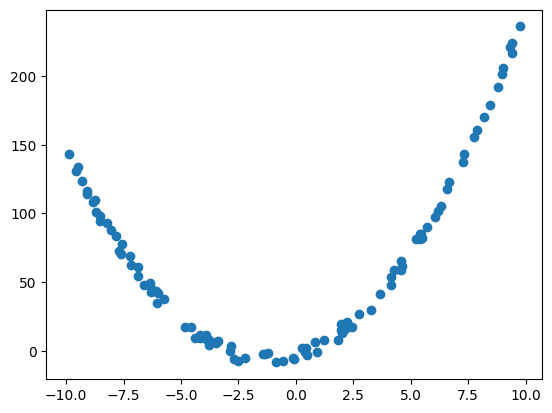

In [6]:
# draw a scatter plot of the data
plt.scatter(df['x'], df['y'])
plt.show()

### What equation will best fit the data? Explain your reason.
    (a) Linear: ax + b
    (b) Quadratic: ax^2 + bx + c
    (c) Other

    The answer is B while the plotted data looks like quadratics, so the best fit would be Quadratic while the reason behind using the equation is to mimic the train data


### Gradient Descent One Step

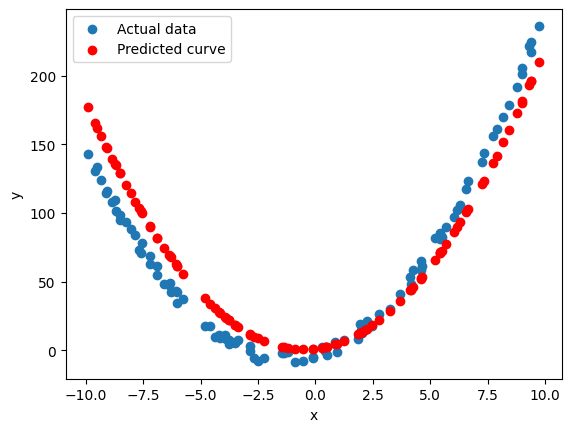

In [7]:
# Define a function to predict y given x
# Initialize the function (with some dummy coefficients) and plot the curve along with the scatter plot
data = {
    'x': np.random.rand(100),
    'y': np.random.rand(100)
}
dummy_df = pd.DataFrame(data)
def compute_ypred(x, coeffs):
    y_pred = coeffs[0] * x**2 + coeffs[1] * x + coeffs[2]
    return y_pred
coeffs = [2, 2,1]

df['y_pred'] = compute_ypred(df['x'], coeffs)

plt.scatter(df['x'], df['y'], label='Actual data')
plt.scatter(df['x'], df['y_pred'], color='red', label='Predicted curve')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [8]:
# Define a function to calculate the mean square error
# Print the loss for the y predictions
def calculate_loss(y, y_pred):
    mse = np.mean((y - y_pred) ** 2)
    return mse

y_actual = np.random.rand(100)
y_predicted = np.random.rand(100)

loss = calculate_loss(y_actual, y_predicted)

print(f"The mean square error (MSE) for the predictions is: {loss}")

The mean square error (MSE) for the predictions is: 0.1568627180897514


In [9]:
# Define a function to calculate the partial derivatives
# Print the gradients for the loss
def calculate_gradients(x, y, y_pred):
    dL_dy_pred = -2 * (y - y_pred)
    dL_da = np.mean(dL_dy_pred * x**2)
    dL_db = np.mean(dL_dy_pred * x)
    dL_dc = np.mean(dL_dy_pred)

    return dL_da, dL_db, dL_dc

x = np.random.rand(100)
y_actual = np.random.rand(100)
y_predicted = np.random.rand(100)

gradients = calculate_gradients(x, y_actual, y_predicted)

print(f"The gradients for the loss are: {gradients}")

The gradients for the loss are: (0.042318721688079625, 0.05324996160036229, 0.10342055629408257)


Updated coefficients: [1.999995768127831, 1.99999467500384, 1]
Old loss: 354.1597192587103
New loss: 354.15865591737537


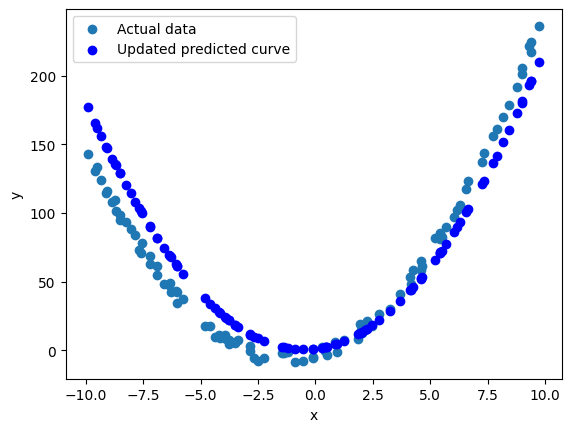

In [10]:
# Now update the coefficints with learning rate = 0.0001 and print them
# Add the a new curve to the previous plot (2 curves and scatter)
# Did the equation improve? Yeah, a little bit
learning_rate = 0.0001
coeffs[0] -= learning_rate * gradients[0]
coeffs[1] -= learning_rate * gradients[1]
print(f"Updated coefficients: {coeffs}")

df['y_pred_updated'] = compute_ypred(df['x'], coeffs)
old_loss = calculate_loss(df['y'], df['y_pred'])
print(f"Old loss: {old_loss}")
new_loss = calculate_loss(df['y'], df['y_pred_updated'])
print(f"New loss: {new_loss}")

plt.scatter(df['x'], df['y'], label='Actual data')
plt.scatter(df['x'], df['y_pred_updated'], color='blue', label='Updated predicted curve')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

### Gradient Descent Loop

In [11]:
# Finally we will perform gradient descent iteratively over some epochs
# Put everything before together in a function
# save the computed loss after each epoch
def gradient_descent(x, y, lr=0.0001, n_epochs=1000):
    coeffs = [0.5, 2.0, 1.0]

    loss_history = []

    for epoch in range(n_epochs):
        y_pred = compute_ypred(x, coeffs)

        loss = calculate_loss(y, y_pred)
        loss_history.append(loss)

        gradients = calculate_gradients(x, y, y_pred)

        coeffs[0] -= lr * gradients[0]
        coeffs[1] -= lr * gradients[1]
        coeffs[2] -= lr * gradients[2]

        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss}")

    return coeffs, loss_history


Epoch 100/1000, Loss: 93.96702329939973
Epoch 200/1000, Loss: 34.6600329948881
Epoch 300/1000, Loss: 19.81978949139456
Epoch 400/1000, Loss: 16.047644768760772
Epoch 500/1000, Loss: 15.03139308286573
Epoch 600/1000, Loss: 14.702289312415395
Epoch 700/1000, Loss: 14.545447850418231
Epoch 800/1000, Loss: 14.432704672341231
Epoch 900/1000, Loss: 14.332142530286959
Epoch 1000/1000, Loss: 14.23579819712021


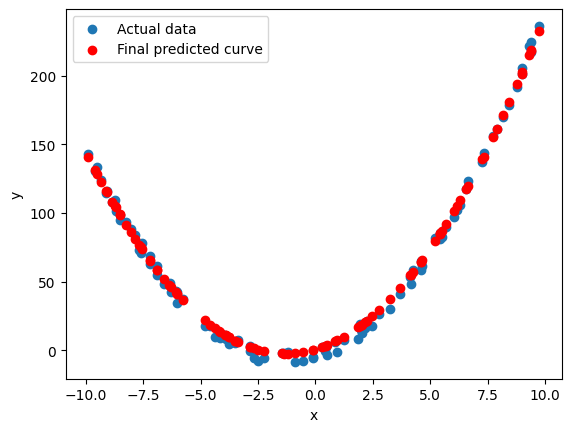

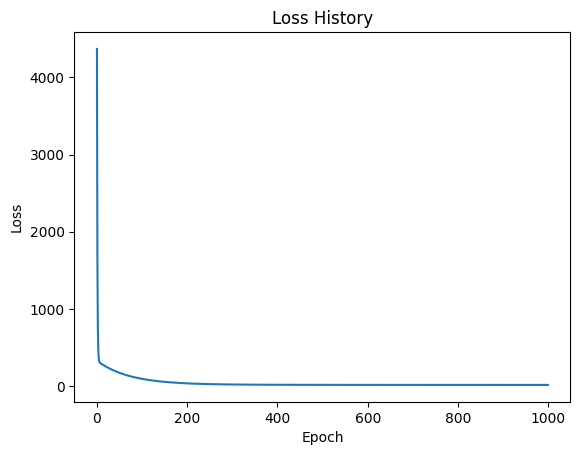

Final coefficients: [1.9376238687945608, 4.9733281557329345, 0.7086084800752269]


In [12]:
# Run for a few hundred epochs and plot the final equation
# How did the curve fit to the input data?
# the curve very close from the actual data and the loss was decreasing
coeffs, loss_history = gradient_descent(df['x'], df['y'], lr=0.0001, n_epochs=1000)

df['y_pred_final'] = compute_ypred(df['x'], coeffs)

plt.scatter(df['x'], df['y'], label='Actual data')
plt.scatter(df['x'], df['y_pred_final'], color='red', label='Final predicted curve')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss History')
plt.show()

print(f"Final coefficients: {coeffs}")

# Q2: Building National Stadiums (15 pts)

You are given the coordinates (latitude and longitude) of soccer stadiums in Europe.
(https://raw.githubusercontent.com/jokecamp/FootballData/master/other/stadiums-with-GPS-coordinates.csv)

Choose any country from the given dataset. You are tasked to build the national stadium for the country.

Find the location of this national stadium such that the average distance from all other stadiums is minimum.

In [13]:
# import necessary libraries
import torch
import folium
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from branca.element import Figure

In [14]:
# Load the dataset and display few lines for the country you have chosen
# How many stadiums are in the country
# Country: Jordan
df = pd.read_csv('https://raw.githubusercontent.com/jokecamp/FootballData/master/other/stadiums-with-GPS-coordinates.csv')
country = df[df['Country'] == 'Spain']

print(country.head())
print(f"the size: {country.shape},\n\n the value_counts: {country['Stadium'].value_counts().sum()}")

                Team      FDCOUK        City                    Stadium  \
85          Almería      Almeria    Almería   Estadio del Mediterráneo    
86  Athletic Bilbao   Ath Bilbao     Bilbao                  San Mamés    
87  Atlético Madrid   Ath Madrid     Madrid           Vicente Calderón    
88        Barcelona    Barcelona  Barcelona                   Camp Nou    
89            Betis        Betis    Seville          Benito Villamarín    

    Capacity   Latitude  Longitude Country  
85     22000  36.840000  -2.435278   Spain  
86     53332  43.264284  -2.950366   Spain  
87     54851  40.401719  -3.720606   Spain  
88     99354  41.380870   2.122802   Spain  
89     52500  37.356389  -5.981389   Spain  
the size: (25, 8),

 the value_counts: 25


In [15]:
# Mark the coordinates on a map using folium
# You can look up how to do it online
# i have done it for the country that I have chosen, actually this is amazing :)
latlon = list(zip(country['Latitude'], country['Longitude']))
midp = [country['Latitude'].mean(), country['Longitude'].mean()]

fig = Figure(width=600, height=400)
map = folium.Map(location=midp, zoom_start=5)

for point in range(0, len(latlon)):
    folium.Marker(latlon[point], popup=df['Stadium'][point]).add_to(map)
fig.add_child(map)
map

## Walkthrough
Solve this problem using gradient descent. You will have to answer these questions to get to the solution.
1. What are the variables that will be optimized, i.e., $x$? How many are there?
The variables that will be optimized are the latitude and longitude of the national stadium. These are the coordinates we want to adjust to minimize the average distance to all other stadiums.

Variables (x): Latitude (lat) and Longitude (lon)
Number of Variables: 2

2. What is my objective function or loss or $f(x)$, that I will minimize?
The objective function (or loss function) we will minimize is the average Haversine distance between the national stadium and all other stadiums.

Objective Function (f(x)): Average Haversine distance

3. How do I calculate distance between two points from a pair of coordinates?
We calculate the distance between two points using the Haversine formula. This formula gives the distance between two points on the Earth's surface given their latitude and longitude

4. What initial values $x_0$ do I choose? What learning rate and number of epochs do I choose?
Initial Values (x0): We can start with the coordinates of a known stadium, such as the Santiago Bernabéu Stadium in Madrid.
Initial Latitude: 40.4531
Initial Longitude: -3.6883
Learning Rate (lr): A small value, such as 0.002, to ensure stable convergence.
Number of Epochs (n_epochs): A sufficient number to allow the algorithm to converge, such as 200.

### One Gradient Descent Step

In [16]:
# Your variables x are the latitude and longitude of the stadium
# Initialize them with some dummy lat, long value (preferably close to the country you've chosen)
lat = 40.4531
lon = -3.6883

print(f"Latitude: {lat}, Longitude: {lon}")

Latitude: 40.4531, Longitude: -3.6883


In [17]:
# Also have an array of all the latitudes and all the longitudes of the given stadiums
latitudes = df['Latitude'].to_numpy()
longitudes = df['Longitude'].to_numpy()
print("Latitudes:", latitudes)
print("Longitudes:", longitudes)

Latitudes: [51.555    52.509167 53.728611 53.580556 51.481667 53.438889 51.475
 53.430819 53.482989 53.463056 54.975556 52.622128 51.509167 52.988333
 54.9144   51.6422   51.603333 52.509167 53.547778 52.590278 53.552222
 52.475703 53.804722 50.861822 51.44     53.789167 51.472778 52.448056
 51.398333 52.915    53.509722 53.746111 52.055061 53.777778 52.620278
 54.578333 51.485953 52.94     52.564697 50.796389 51.422222 50.905833
 51.649836 51.531944 55.886167 57.494722 55.849711 56.475264 56.075308
 55.961667 56.005136 55.779947 55.881556 55.853206 56.409686 55.782156
 57.159167 55.604225 55.850556 56.474703 55.939167 57.595947 48.3225
 51.038256 48.218775 51.492569 51.174583 52.29     50.068572 47.988889
 53.587158 52.360067 52.514722 49.239008 49.984167 49.426111 51.554503
 48.792269 53.066394 52.431944 51.261667 49.486944 49.434722 50.933497
 53.554444 36.84     43.264284 40.401719 41.38087  37.356389 42.211842
 38.266944 41.347861 40.325556 37.152967 39.494722 36.734092 42.796667


To convert an array/number n to tensor : `n1 = torch.tensor(n).requires_grad_(True)`

In [18]:
# Convert all inputs and arrays to torch tensors and set requires grad = True
# Pytorch will calculate the partial derivates so we don't have to do anything
latitudes = torch.tensor(latitudes).requires_grad_(True)
longitudes = torch.tensor(longitudes).requires_grad_(True)

### Haversine Distance
Gives the distance between two points on the earth's surface

https://stackoverflow.com/questions/4913349/haversine-formula-in-python-bearing-and-distance-between-two-gps-points

Instead of using math library we will use torch.

Useful functions:
- Convert degrees to radians: `torch.deg2rad()`
- Trig functions: `torch.sin()`, `torch.cos()`, etc.
- Arithmetic: `torch.sqrt()`
- Radius of Earth: `6371 km`

In [19]:
# Define a function to calculate haversine distance
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1 = torch.deg2rad(lat1)
    lon1 = torch.deg2rad(lon1)
    lat2 = torch.deg2rad(lat2)
    lon2 = torch.deg2rad(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = torch.sin(dlat / 2) ** 2 + torch.cos(lat1) * torch.cos(lat2) * torch.sin(dlon / 2) ** 2
    c = 2 * torch.atan2(torch.sqrt(a), torch.sqrt(1 - a))

    R = 6371

    distance = R * c

    return distance
# the distance between madrid and barclona
lat1 = torch.tensor(40.4168, dtype=torch.float32).requires_grad_(True)
lon1 = torch.tensor(-3.7038, dtype=torch.float32).requires_grad_(True)
lat2 = torch.tensor(41.3851, dtype=torch.float32).requires_grad_(True)
lon2 = torch.tensor(2.1734, dtype=torch.float32).requires_grad_(True)

distance = haversine_distance(lat1, lon1, lat2, lon2)
print(f"Haversine distance: {distance.item()} km")

Haversine distance: 505.44342041015625 km


### Warning
For the torch to compute the gradients, all non-symbolic operations must be in torch.

For example, to find sum, max or average, you should use `torch.sum()`, `torch.max()` or `torch.mean()`

Symbolic operations like `+ - * / **` can be used as it is.

You free to look up solutions online if you are stuck with some error.

In [20]:
# Calculate the haversine distance between any two stadiums
# Use google to confirm your formula is correct
lat1 = torch.tensor(40.4168, dtype=torch.float32).requires_grad_(True)
lon1 = torch.tensor(-3.7038, dtype=torch.float32).requires_grad_(True)
lat2 = torch.tensor(41.3851, dtype=torch.float32).requires_grad_(True)
lon2 = torch.tensor(2.1734, dtype=torch.float32).requires_grad_(True)

distance = haversine_distance(lat1, lon1, lat2, lon2)
print(f"Haversine distance: {distance.item()} km")
# How i confirmed i opened google Earth
# use the measure distance between Madrid and Barceolna and it was very close from this value # 505,054.03 m
# ignored the small difference while it depends on where you pick the point in google earth exactly

Haversine distance: 505.44342041015625 km


In [21]:
# Define a function to calculate loss
# Loss will be the average distance between our national stadium and all other stadiums
# Print the loss you get
def compute_loss(national_lat, national_lon, latitudes, longitudes):
    total_distance = 0
    num_stadiums = len(latitudes)

    for i in range(num_stadiums):
        distance = haversine_distance(national_lat, national_lon, latitudes[i], longitudes[i])
        total_distance += distance

    average_distance = total_distance / num_stadiums
    return average_distance

### Gradients in torch
To calculate gradient, first compute loss and then backpropagate.

`loss = compute_loss()`

`loss.backward()`

The gradient of `x` is stored in `x.grad`

In [22]:
# Find the gradients for your variables and print them
# Update the variable using the gradient you obtained, and print them
# Let learning rate = 0.001
national_lat = torch.tensor(lat, dtype=torch.float32).requires_grad_(True)
national_lon = torch.tensor(lon, dtype=torch.float32).requires_grad_(True)
loss = compute_loss(national_lat, national_lon, latitudes, longitudes)
print(f"Average distance (loss): {loss.item()} km")

loss.backward()

lr = 0.001

# Your code to print gradients

print("Gradient with respect to national_lat:", national_lat.grad)
print("Gradient with respect to national_lon:", national_lon.grad)
# Your code to update lat and lon
with torch.no_grad():
    national_lat -= lr * national_lat.grad
    national_lon -= lr * national_lon.grad

print("Updated national_lat:", national_lat.item())
print("Updated national_lon:", national_lon.item())

Average distance (loss): 1173.8674812689821 km
Gradient with respect to national_lat: tensor(-79.3807)
Gradient with respect to national_lon: tensor(-23.1037)
Updated national_lat: 40.53247833251953
Updated national_lon: -3.665196180343628


Reset gradients of x using `torch.grad.data.zero_()`

In [23]:
# Now put everything together again
# Some extra steps are needed here
# Feel free to change lr or n_epochs as suited

def gradient_descent(lat_of_given_stadiums, lon_of_given_stadiums, lr=0.002, n_epochs=500):
    lat = 40.4531
    lon = -3.6883
    lat = torch.tensor(lat, dtype=torch.float32).requires_grad_(True) # this the initial, it can be changed
    lon = torch.tensor(lon, dtype=torch.float32).requires_grad_(True) # this the initial it can be changed

    loss_list = []

    for e in range(n_epochs):
        loss = compute_loss(lat, lon, lat_of_given_stadiums, lon_of_given_stadiums)
        loss_list.append(loss.item())

        loss.backward()

        with torch.no_grad():
            lat -= lr * lat.grad
            lon -= lr * lon.grad

        lat.grad.zero_()
        lon.grad.zero_()

    return lat.item(), lon.item(), loss_list




In [25]:
# Run your gradient descent for your choice of epochs
# Print the final coordinates of the national stadium
latitudes = df['Latitude'].to_numpy()
longitudes = df['Longitude'].to_numpy()

latitudes = torch.tensor(latitudes, dtype=torch.float32).requires_grad_(True)
longitudes = torch.tensor(longitudes, dtype=torch.float32).requires_grad_(True)

FINAL_LAT, FINAL_LON,_ = gradient_descent(latitudes, longitudes)

print("Final LAT:", FINAL_LAT)
print("Final LOG:", FINAL_LON)

Final LAT: 51.39805221557617
Final LOG: -0.0754515528678894


In [26]:
# Let's mark the national stadium on a map
# The output should give you a good idea if everything worked
latlon = list(zip(df['Latitude'], df['Longitude']))

midp = [df['Latitude'].mean(), df['Longitude'].mean()]

fig = Figure(width=600, height=400)
map = folium.Map(location=midp, zoom_start=5)

for point in range(0, len(latlon)):
    folium.Marker(latlon[point], popup=df['Stadium'][point]).add_to(map)


stad = folium.Marker((FINAL_LAT, FINAL_LON), popup='NATIONAL', icon=folium.Icon(color='red'), z_index_offset=1000).add_to(map)
map.keep_in_front(stad)
fig.add_child(map)
map

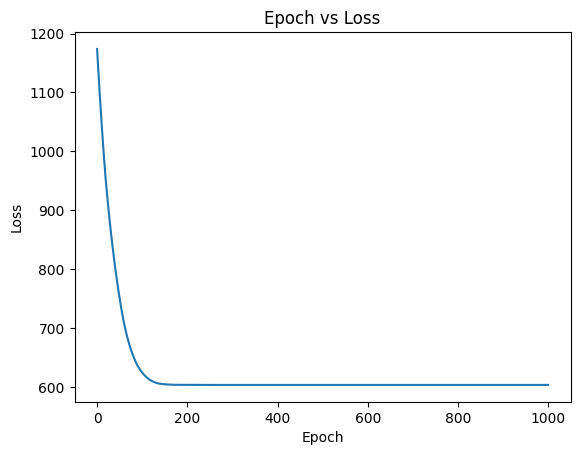

In [27]:
# Plot the epoch (x-axis) vs loss (y-axis) graph
# Show that the loss decreases and then converges to a minimum
import matplotlib.pyplot as plt


latitudes = df['Latitude'].to_numpy()
longitudes = df['Longitude'].to_numpy()

latitudes = torch.tensor(latitudes, dtype=torch.float32).requires_grad_(True)
longitudes = torch.tensor(longitudes, dtype=torch.float32).requires_grad_(True)

FINAL_LAT, FINAL_LON,loss_list = gradient_descent(latitudes, longitudes)

plt.plot(range(len(loss_list)), loss_list)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Epoch vs Loss')
plt.show()